In [49]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load env vars if python-dotenv is available (optional)
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass  # pip install python-dotenv for local .env support

# Mount Google Drive only on Colab, safely skip locally
try:
    from google.colab import drive
    if os.path.exists('/content') and not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
except ImportError:
    pass


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
# Resolve CSV path via .env (COLAB_CSV_PATH) with fallback for both environments
COLAB_PATH = os.getenv('COLAB_CSV_PATH', '/content/drive/MyDrive/Test 3/Instagram_Analytics.csv')
LOCAL_PATH = os.getenv('LOCAL_CSV_PATH', 'Instagram_Analytics.csv')
csv_path = COLAB_PATH if os.path.exists(COLAB_PATH) else LOCAL_PATH
print(f'Loading dataset from: {csv_path}')
df = pd.read_csv(csv_path)
df.head()


In [51]:
df.head()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  object 
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  object 
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  object 
 5   content_category          29999 non-null  object 
 6   traffic_source            29999 non-null  object 
 7   has_call_to_action        29999 non-null  int64  
 8   post_datetime             29999 non-null  object 
 9   post_date                 29999 non-null  object 
 10  post_hour                 29999 non-null  int64  
 11  day_of_week               29999 non-null  object 
 12  likes                     29999 non-null  int64  
 13  comments                  29999 non-null  int64  
 14  shares

In [53]:
df.describe()

,account_id,follower_count,has_call_to_action,post_hour,likes,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count
count,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000
mean,10.567819,10278.305477,0.348778,11.499417,287.653588,8.521917,14.426614,42.517284,6272.475449,8466.952498,0.042107,502.152805,120.081169,7.987933
std,5.763952,6691.862669,0.476592,6.900587,317.647682,10.116505,16.420899,47.808844,4985.877059,6825.900355,0.024095,290.364038,11.009108,2.828130
min,1.000000,3083.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,268.000000,327.000000,0.000000,0.000000,70.000000,0.000000
25%,6.000000,5824.000000,0.000000,6.000000,104.000000,3.000000,5.000000,15.000000,3058.000000,4102.000000,0.024000,251.000000,113.000000,6.000000
50%,11.000000,9044.000000,0.000000,12.000000,199.000000,6.000000,10.000000,29.000000,4913.000000,6595.000000,0.040600,501.000000,120.000000,8.000000
75%,16.000000,10739.000000,1.000000,17.000000,363.000000,11.000000,19.000000,54.000000,7863.000000,10620.500000,0.057000,755.000000,127.000000,10.000000
max,20.000000,31095.000000,1.000000,23.000000,10632.000000,339.000000,516.000000,1542.000000,73339.000000,105203.000000,0.271000,1000.000000,166.000000,21.000000


In [54]:
for col in df.columns:
  print(col)
  print(f"{df[col].unique()} \n number of unique {df[col].nunique()}",)
  print('--'*50)

post_id
['IG0000001' 'IG0000002' 'IG0000003' ... 'IG0029997' 'IG0029998'
 'IG0029999'] 
 number of unique 29999
----------------------------------------------------------------------------------------------------
account_id
[ 7 20 15 11  8 19  4  3  2 12  6  1 17 10 16  5  9 18 14 13] 
 number of unique 20
----------------------------------------------------------------------------------------------------
account_type
['brand' 'creator'] 
 number of unique 2
----------------------------------------------------------------------------------------------------
follower_count
[ 3551 31095  8167  9044 15986  3447  4972 10018 22291 13798 10034  9461
 15923  4542  9696 10739  6916  7486  3083  5824] 
 number of unique 20
----------------------------------------------------------------------------------------------------
media_type
['reel' 'image' 'carousel'] 
 number of unique 3
----------------------------------------------------------------------------------------------------
content_catego

In [55]:
catcol = (
    df.select_dtypes(include='object')
    .drop(columns=['day_of_week', 'post_date', 'post_datetime', 'post_id'])
    .columns.tolist()
)

catcol.append('has_call_to_action')

exclude_cols = set(catcol + ['post_id', 'account_id', 'post_datetime', 'post_date', 'day_of_week','post_hour'])

numcol = df.drop(columns=[c for c in exclude_cols if c in df.columns]).columns.tolist()

In [56]:
catcol

['account_type',
 'media_type',
 'content_category',
 'traffic_source',
 'performance_bucket_label',
 'has_call_to_action']

In [57]:
numcol

['follower_count',
 'likes',
 'comments',
 'shares',
 'saves',
 'reach',
 'impressions',
 'engagement_rate',
 'followers_gained',
 'caption_length',
 'hashtags_count']

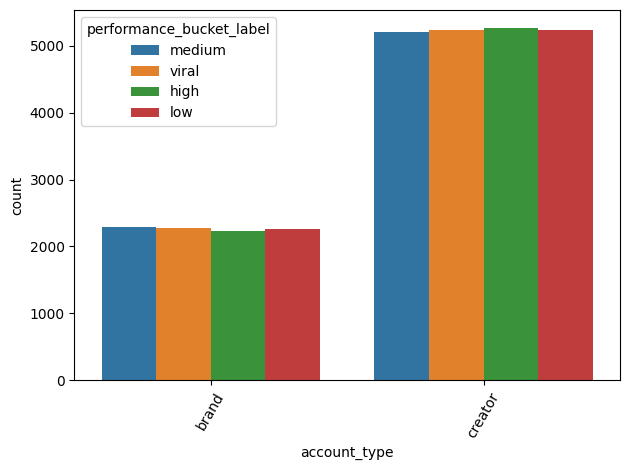

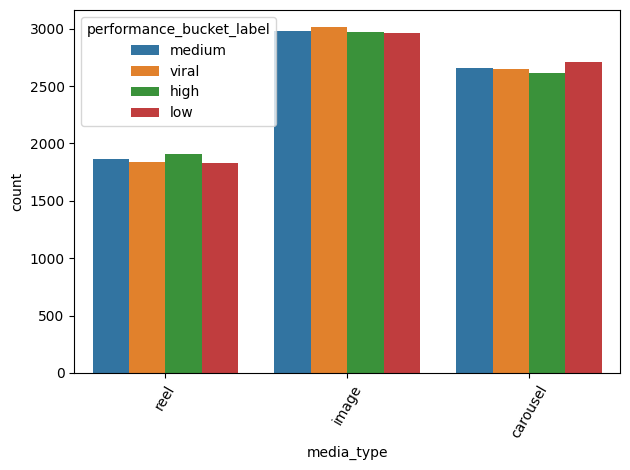

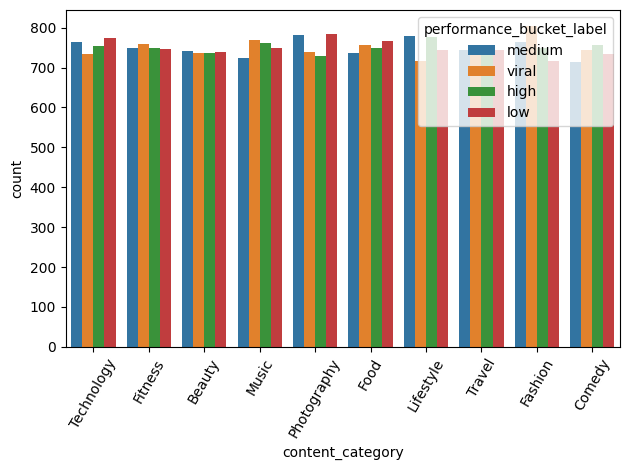

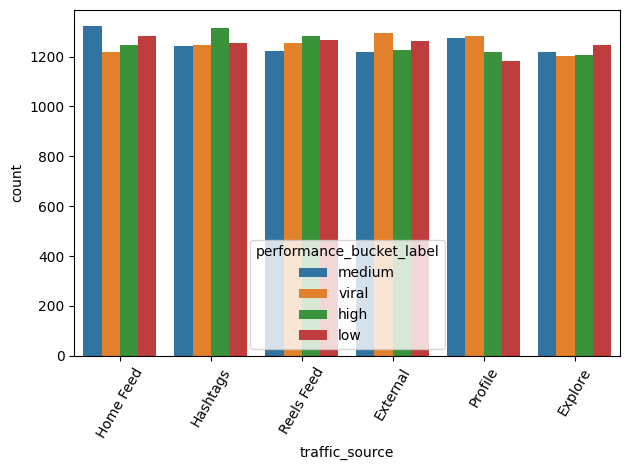

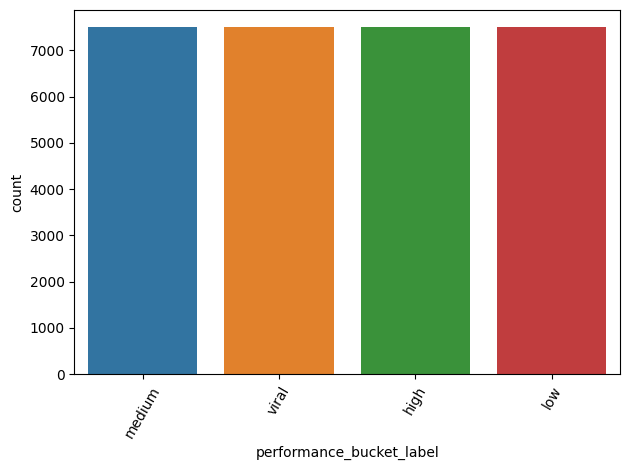

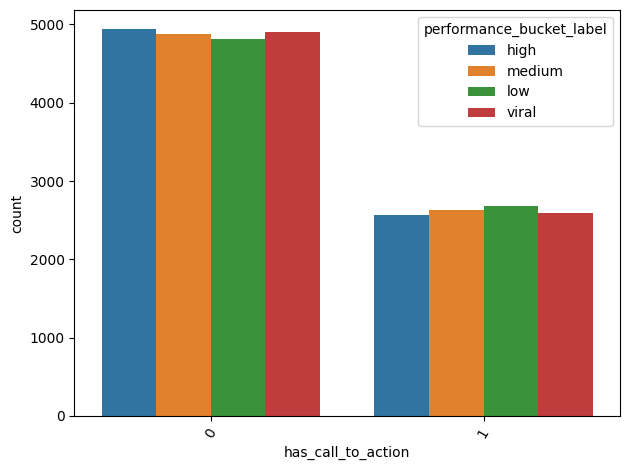

In [58]:
for col in catcol:
  sns.countplot(x=col,data=df,hue='performance_bucket_label')
  plt.xticks(rotation=60)
  plt.tight_layout()
  plt.show()


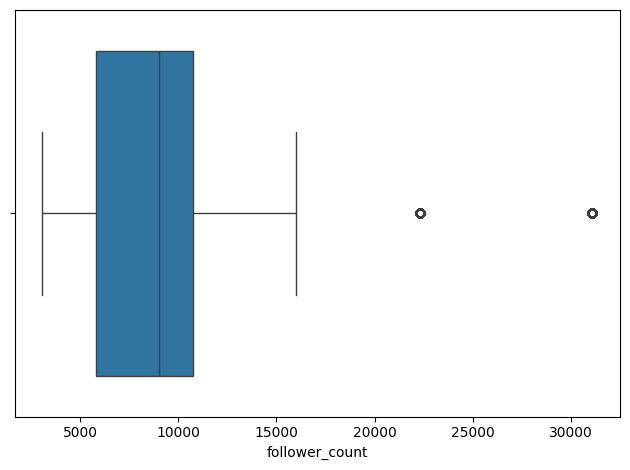

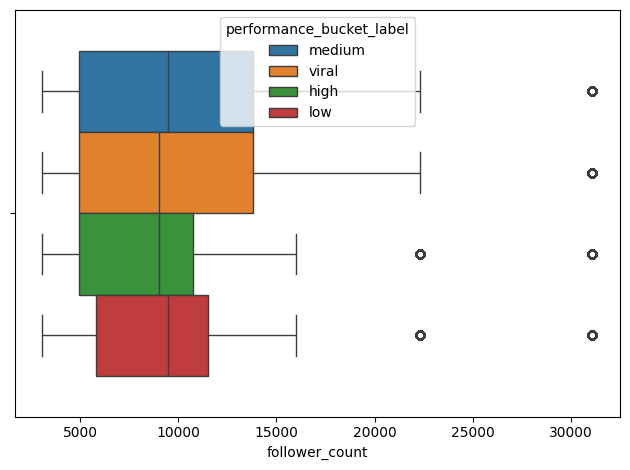

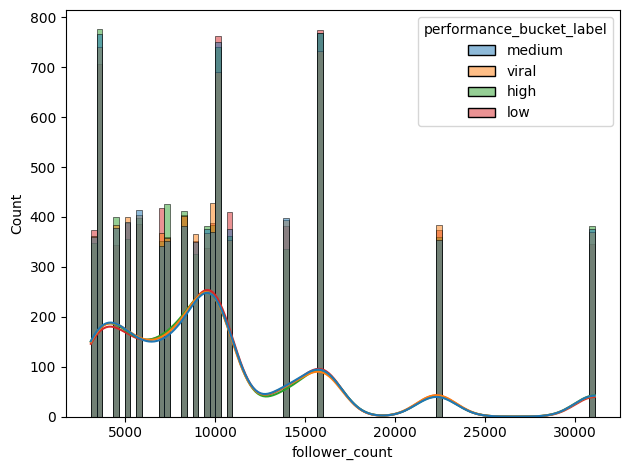

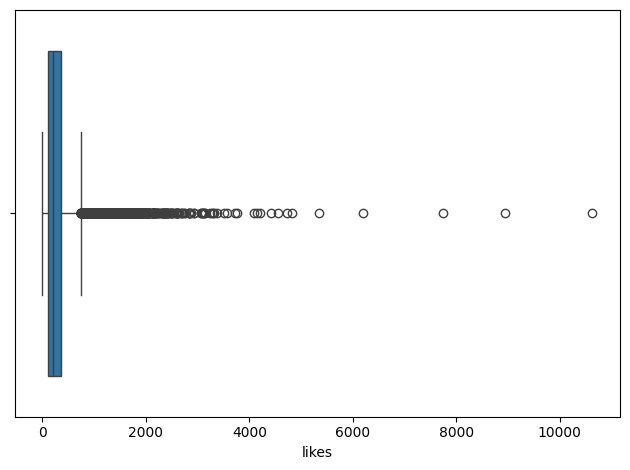

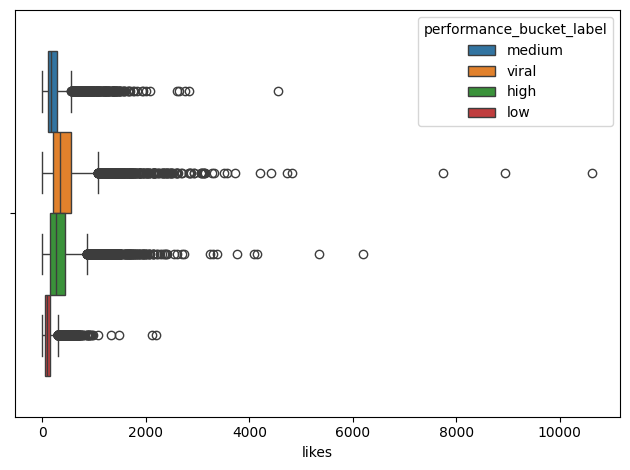

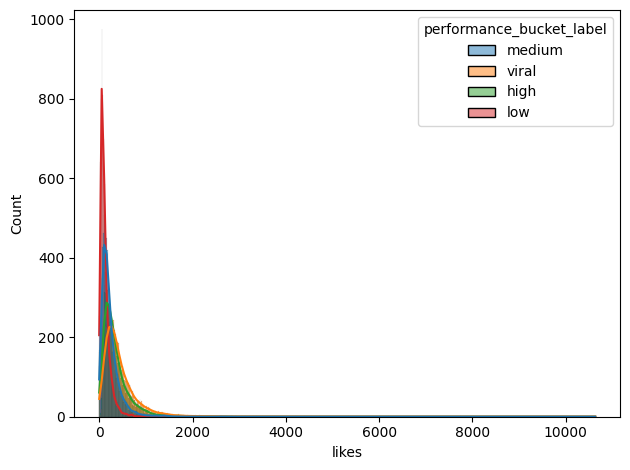

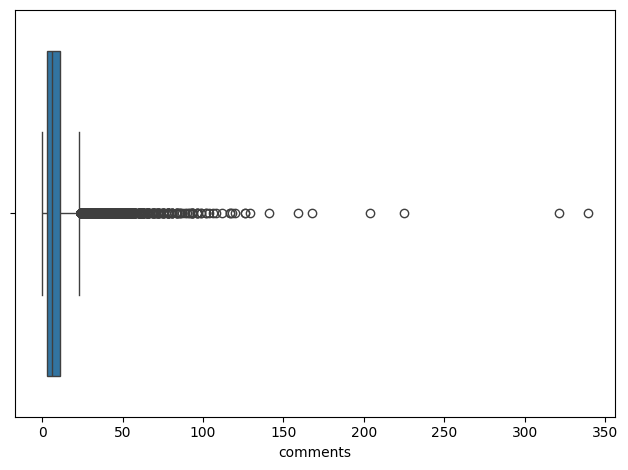

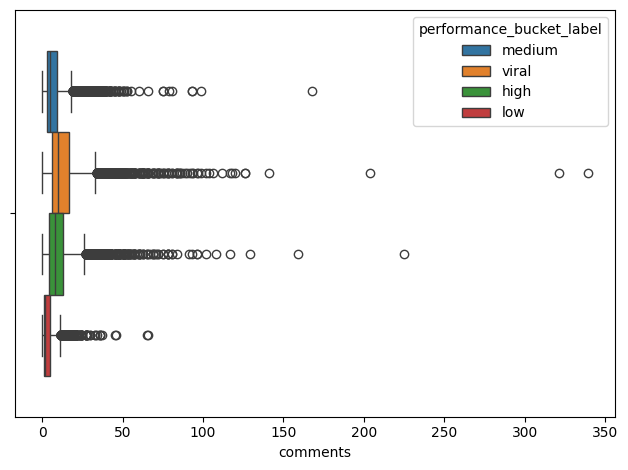

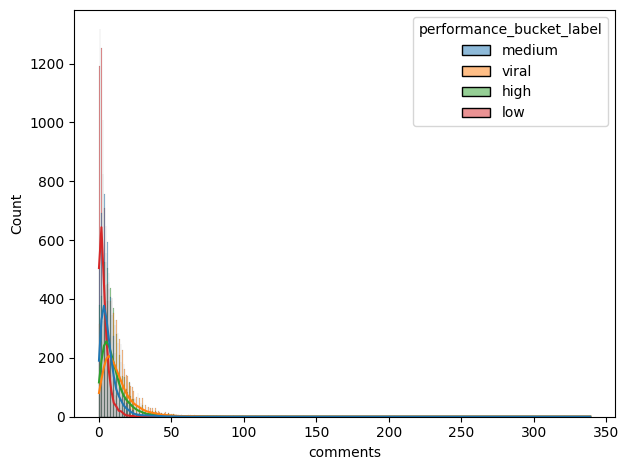

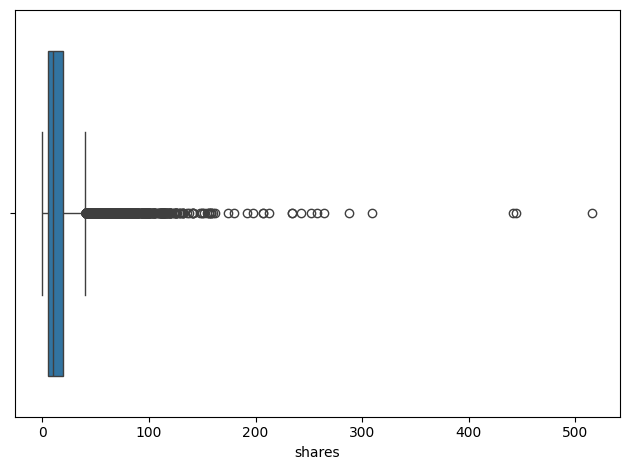

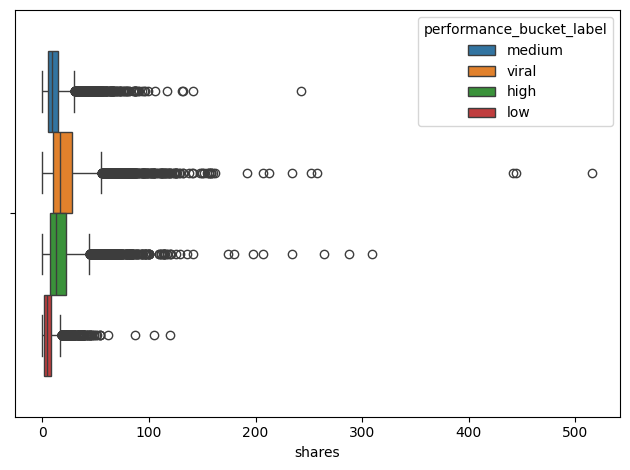

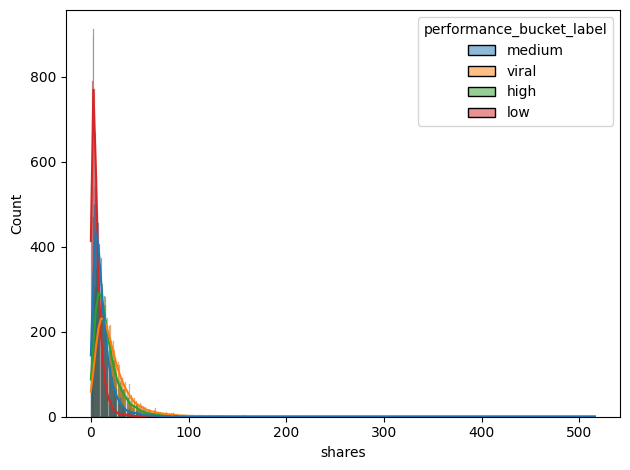

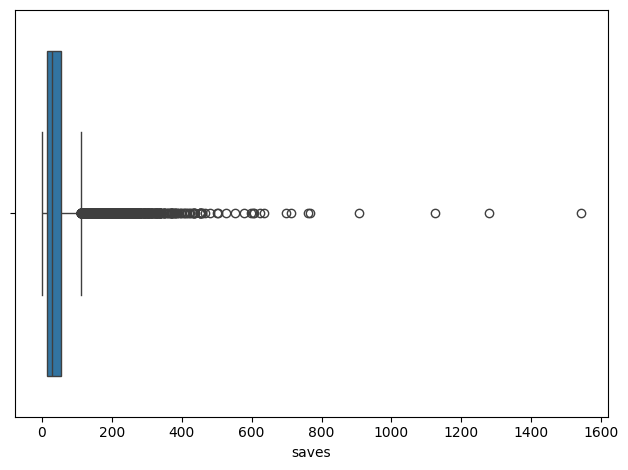

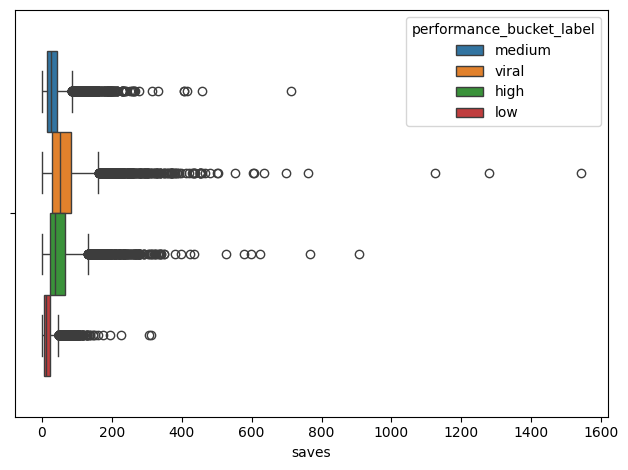

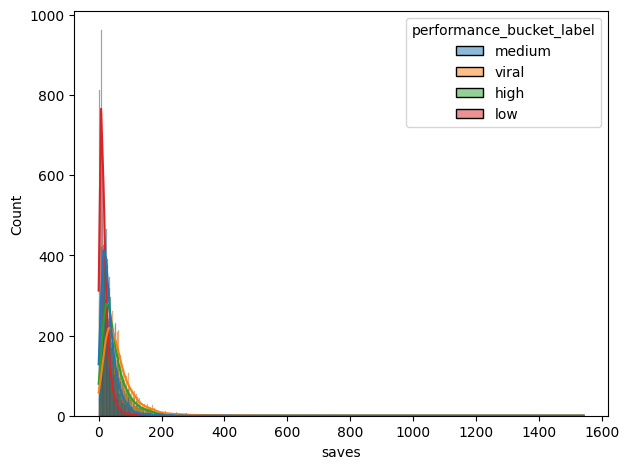

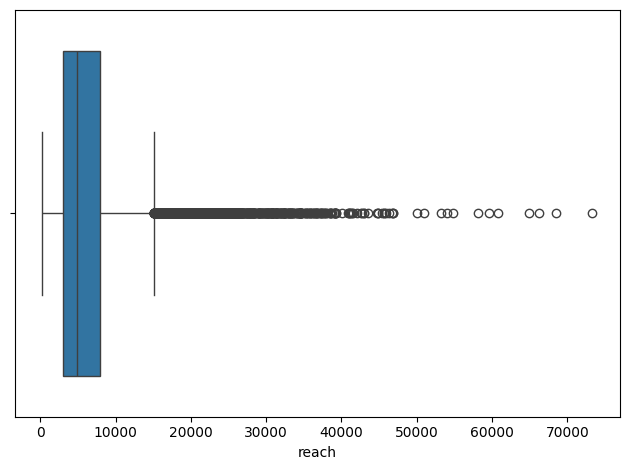

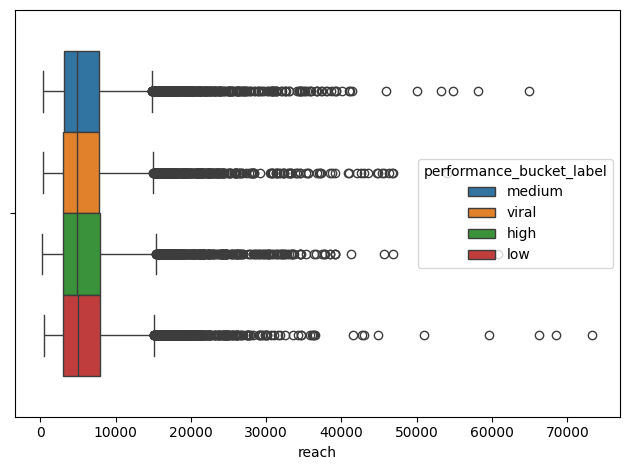

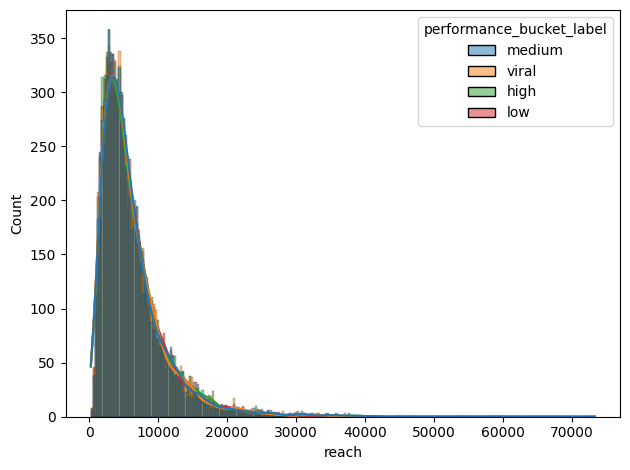

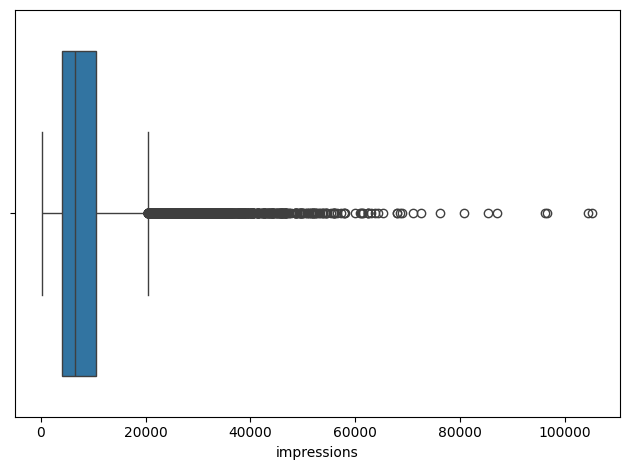

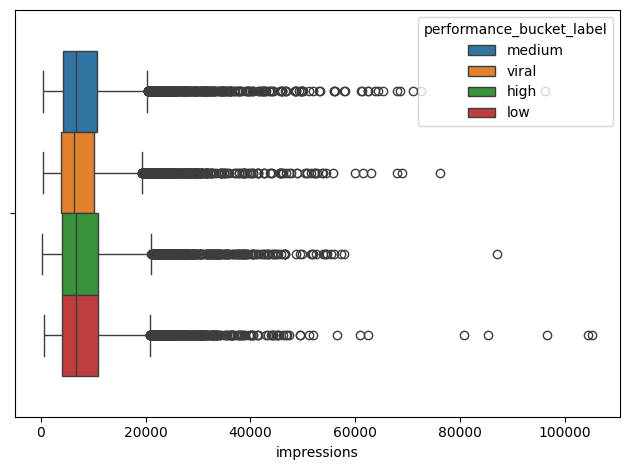

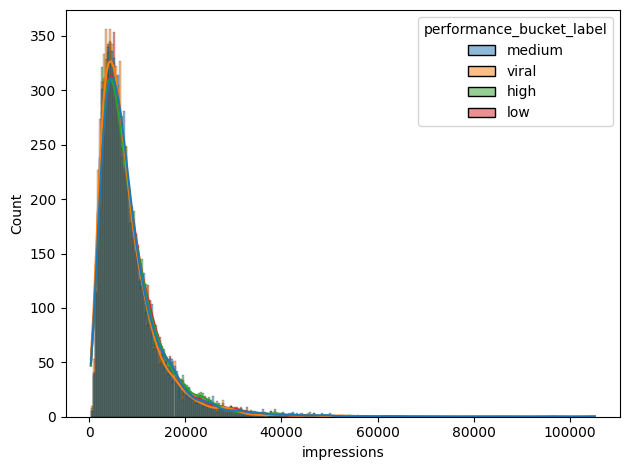

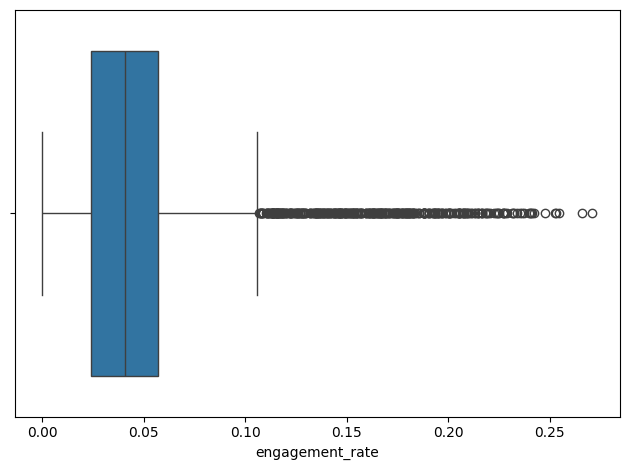

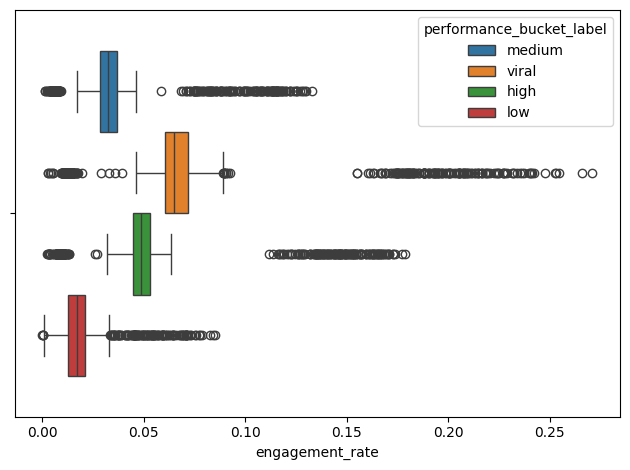

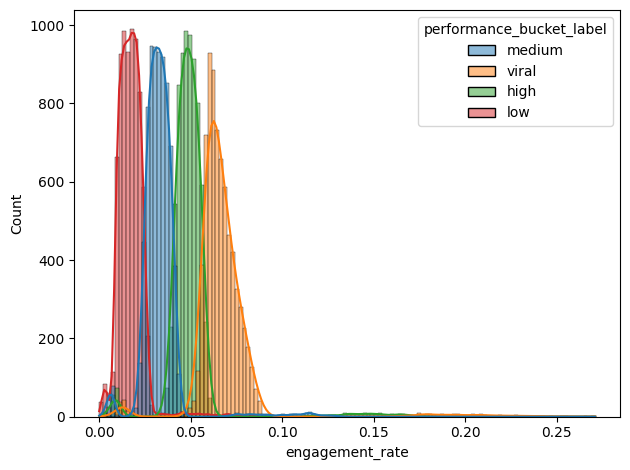

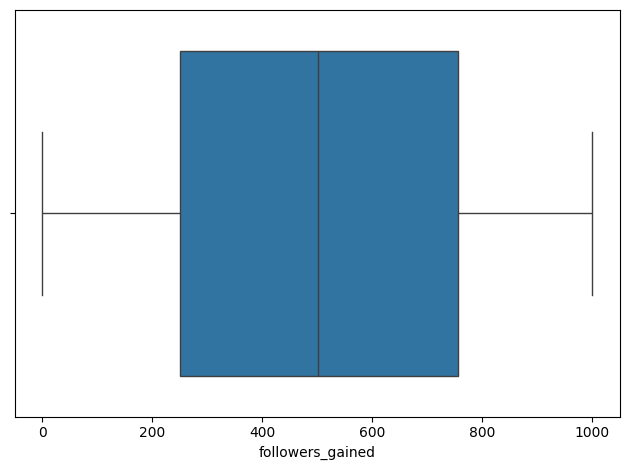

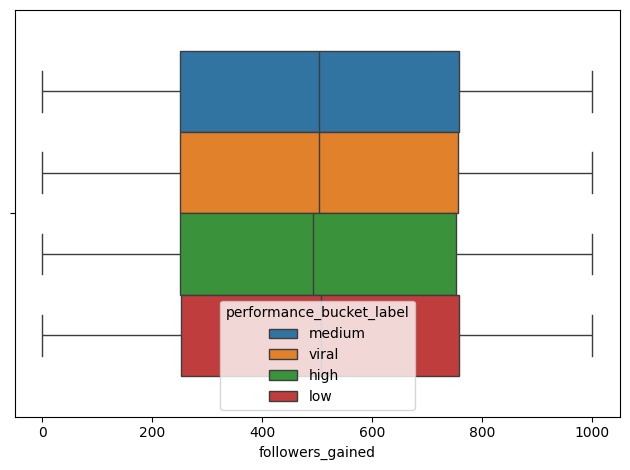

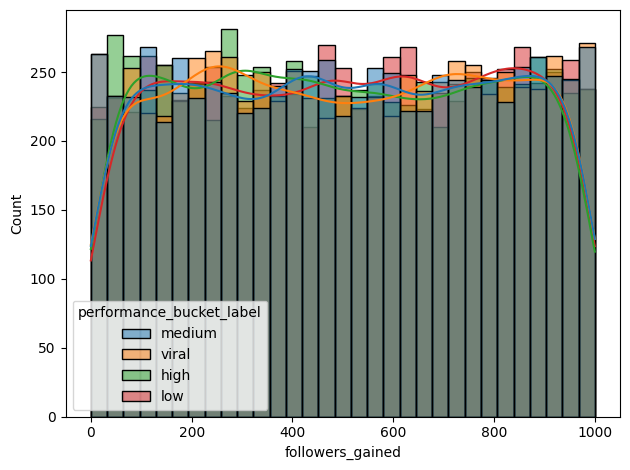

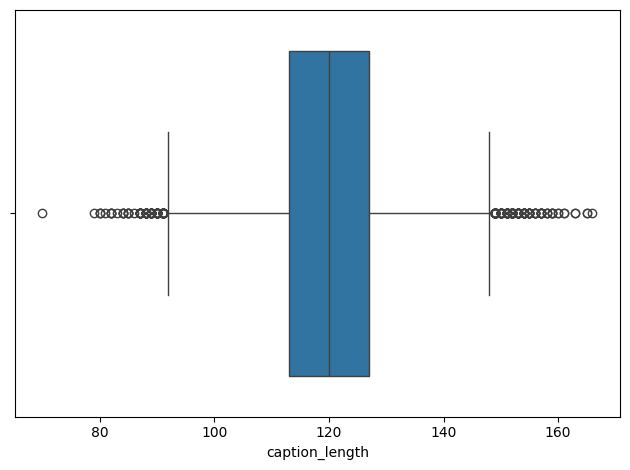

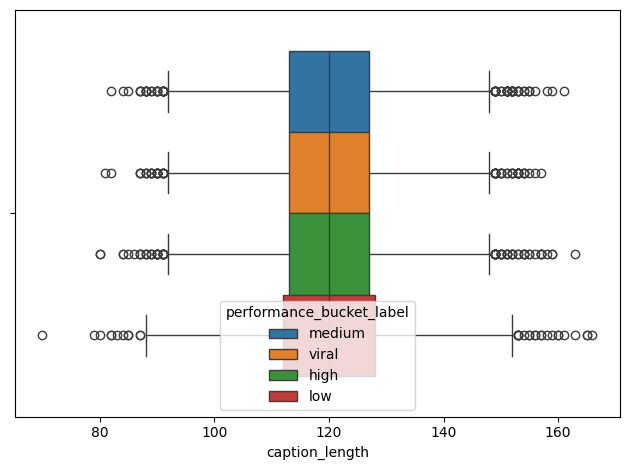

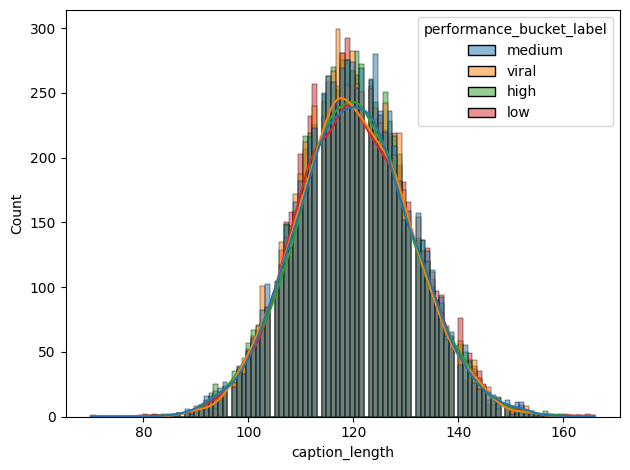

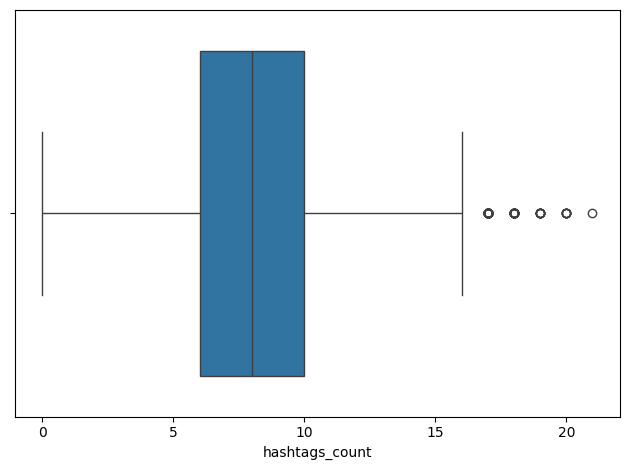

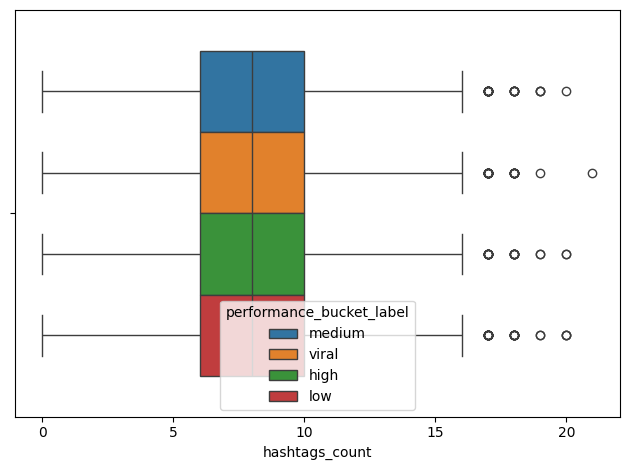

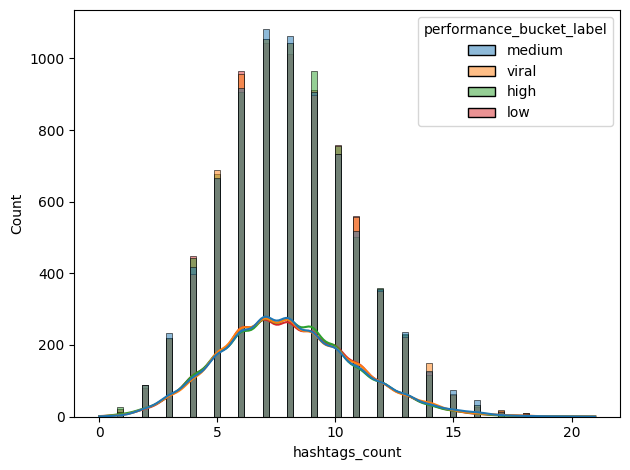

In [59]:
for col in numcol:
  sns.boxplot(x=col,data=df)
  plt.tight_layout()
  plt.show()

  sns.boxplot(x=col,data=df,hue='performance_bucket_label')
  plt.tight_layout()
  plt.show()

  sns.histplot(x=col,data=df,hue='performance_bucket_label',kde=True)
  plt.tight_layout()
  plt.show()

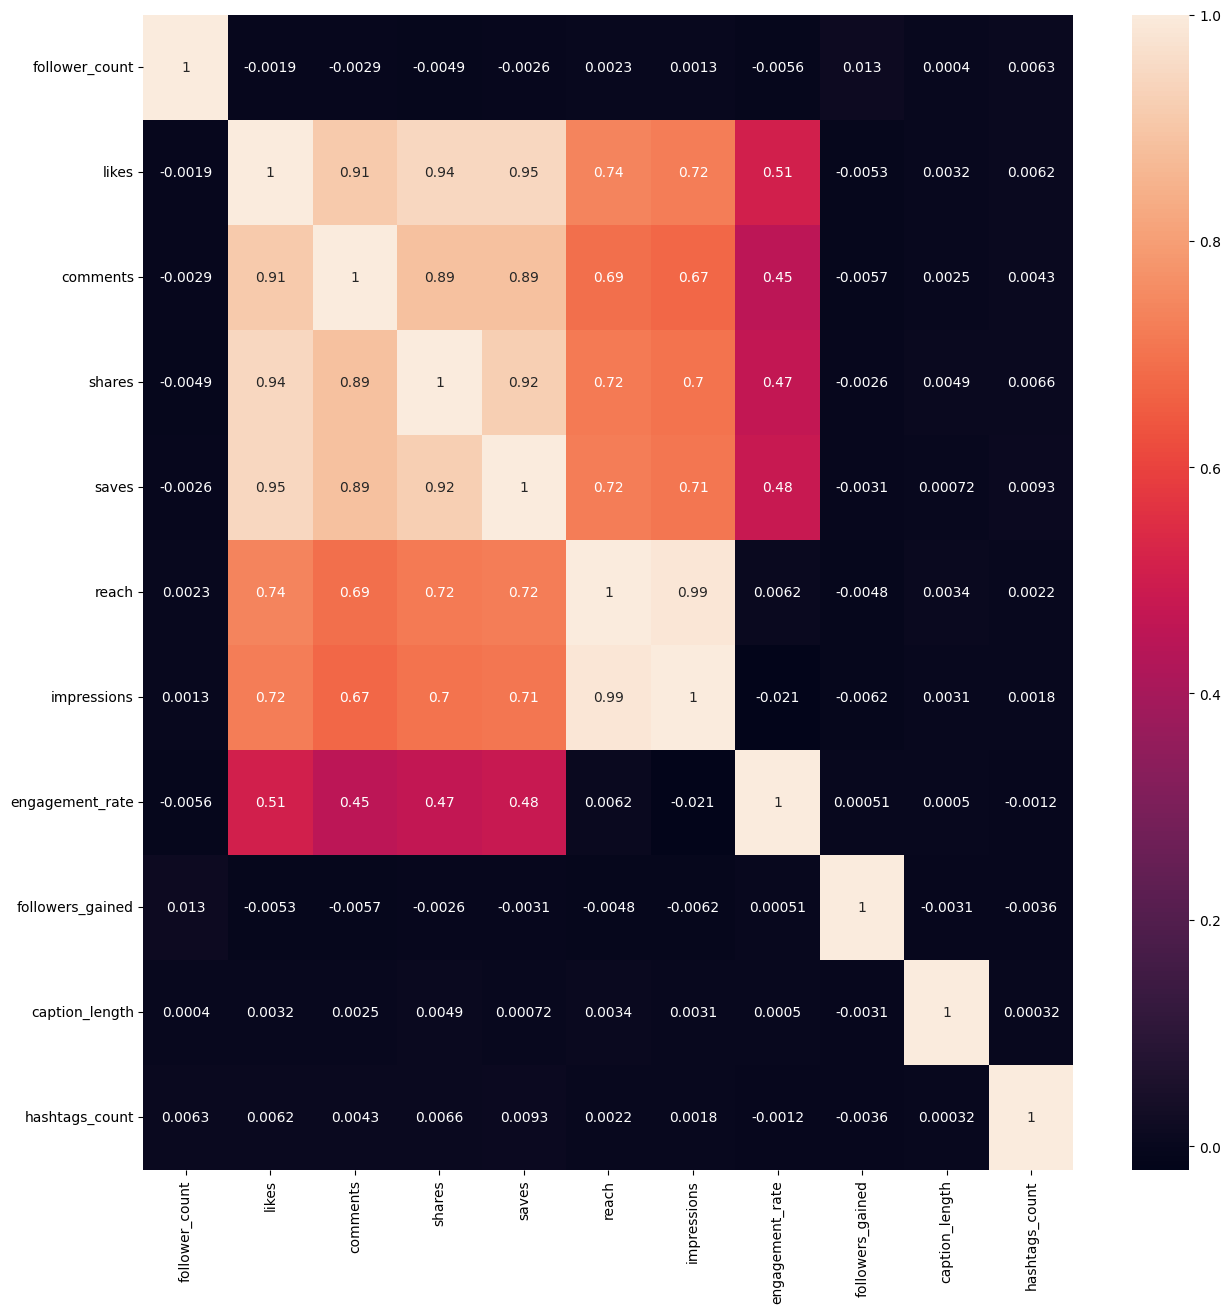

In [62]:
plt.figure(figsize=(15,15))
sns.heatmap(data=df[numcol].corr(),annot=True)
plt.show()